# 04 — Nhánh B: hồi quy tỷ suất biến động

Nhánh phụ này bổ trợ cho nhánh A ở hai điểm:

1. Dùng được bộ chỉ số hồi quy sẵn có (`RMSE`, `MAE`, `R²`, `MAPE`).
2. Cho phép **suy ngược ra chiều biến động** từ dấu của giá trị dự đoán, nhờ đó so
   sánh trực tiếp với nhánh A qua chỉ số Directional Accuracy.

**Một lưu ý quan trọng về mục tiêu.** Mô hình dựa trên cây **không ngoại suy được**:
mọi dự đoán luôn nằm trong khoảng giá trị đã thấy khi huấn luyện. Nếu đặt mục tiêu
là mức giá tuyệt đối, mô hình sẽ không bao giờ dự đoán được vùng giá mới. Vì vậy
mục tiêu ở đây là **tỷ suất biến động**, đại lượng không có đơn vị và dao động
quanh 0.

In [1]:
import os
import sys

# Đưa src/ vào đường dẫn tìm kiếm module để import được các package của dự án.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

import matplotlib.pyplot as plt
%matplotlib inline

from libraries import rfPlot
from libraries.randomForest import RandomForestRegressor
from pipeline import experiment
from utilities import metrics

## 1. Cấu hình

In [2]:
import json

CONFIG_PATH = os.path.join(PROJECT_ROOT, 'config', 'regression.json')
with open(CONFIG_PATH, encoding='utf-8') as handle:
    config = json.load(handle)

print(config['description'])
print(f"Dữ liệu  : {config['dataset']['path']}")
print(f"Tầm nhìn : {config['labeling']['horizon']} bước")
print(f"Đặc trưng: {sum(1 for item in config['features'] if item.get('keep', True))}")

Nhánh B — hồi quy tỷ suất biến động bằng Random Forest.
Dữ liệu  : data/input/VNM.csv
Tầm nhìn : 5 bước
Đặc trưng: 25


In [3]:
SYMBOL = config['dataset']['label']
MODEL_SETTINGS = dict(config['model'])
MODEL_SETTINGS['verbose'] = 0
MODEL_SETTINGS

{'n_estimators': 300,
 'criterion': 'variance',
 'max_depth': 6,
 'min_samples_split': 2,
 'min_samples_leaf': 30,
 'max_features': 'third',
 'max_thresholds': 48,
 'bootstrap': True,
 'random_state': 42,
 'verbose': 0}

## 2. Chuẩn bị và tách tập

In [4]:
dataset = experiment.prepare_dataset(config, PROJECT_ROOT)
parts = experiment.split_prepared_dataset(config, dataset)

train_samples, train_targets           = parts['train']
validation_samples, validation_targets = parts['validation']
test_samples, test_targets             = parts['test']

feature_names = dataset['feature_names']
test_keys = [dataset['keys'][index] for index in parts['indices'][2]]

print(f"\nMục tiêu: min = {min(dataset['targets']):+.4f} | "
      f"max = {max(dataset['targets']):+.4f} | "
      f"trung bình = {sum(dataset['targets']) / len(dataset['targets']):+.5f}")

Đã đọc file: VNM.csv | Số dòng dữ liệu: 2587
Các cột: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Làm sạch: 2587 → 2587 dòng | gap lớn nhất 8 ngày | biến động bất thường: 0
Đặc trưng: 27 | mẫu dùng được: 2533 (bỏ 54 dòng)
  train       n =  1773  (70.3%)  2016-10-31 → 2023-09-04
  validation  n =   379  (15.0%)  2023-09-12 → 2025-03-05
  test        n =   371  (14.7%)  2025-03-13 → 2026-08-14

Mục tiêu: min = -0.1447 | max = +0.1677 | trung bình = -0.00037


## 3. Minh hoạ giới hạn không ngoại suy

Phép thử trực tiếp: so khoảng giá trị mà mô hình **có thể** dự đoán với khoảng
giá trị thực tế của tập test. Dự đoán luôn bị chặn trong khoảng đã thấy khi huấn
luyện — đây là tính chất cấu trúc của mô hình dựa trên cây, không phải lỗi.

In [5]:
model = RandomForestRegressor(**MODEL_SETTINGS)
model.fit(train_samples, train_targets)

test_predictions = model.predict(test_samples)

print(f'Khoảng mục tiêu trong tập TRAIN : '
      f'[{min(train_targets):+.4f}, {max(train_targets):+.4f}]')
print(f'Khoảng mục tiêu trong tập TEST  : '
      f'[{min(test_targets):+.4f}, {max(test_targets):+.4f}]')
print(f'Khoảng DỰ ĐOÁN trên tập TEST    : '
      f'[{min(test_predictions):+.4f}, {max(test_predictions):+.4f}]')
print('\n→ Dải dự đoán hẹp hơn hẳn dải thực tế: rừng lấy TRUNG BÌNH của nhiều lá,')
print('  nên mọi giá trị cực đoan đều bị san phẳng.')

Khoảng mục tiêu trong tập TRAIN : [-0.1371, +0.1677]
Khoảng mục tiêu trong tập TEST  : [-0.1447, +0.1596]
Khoảng DỰ ĐOÁN trên tập TEST    : [-0.0112, +0.0336]

→ Dải dự đoán hẹp hơn hẳn dải thực tế: rừng lấy TRUNG BÌNH của nhiều lá,
  nên mọi giá trị cực đoan đều bị san phẳng.


## 4. Kiểm định tiến dần

  vòng 1: train =  1076  validate =  214  điểm = 0.0286


  vòng 2: train =  1290  validate =  214  điểm = 0.0326


  vòng 3: train =  1504  validate =  214  điểm = 0.0307


  vòng 4: train =  1718  validate =  214  điểm = 0.0263


  vòng 5: train =  1932  validate =  215  điểm = 0.0214

RMSE trung bình = 0.027911 ± 0.003862


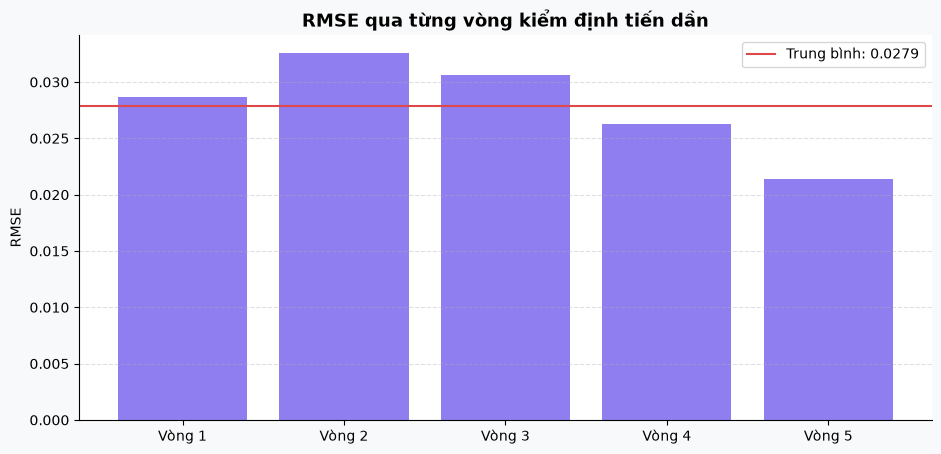

In [6]:
walk_forward = experiment.run_walk_forward(
    config,
    train_samples + validation_samples,
    train_targets + validation_targets,
    model_factory=lambda: RandomForestRegressor(**MODEL_SETTINGS),
    score_function=metrics.calculate_rmse,
)
print(f"\nRMSE trung bình = {walk_forward['mean']:.6f} "
      f"± {walk_forward['standard_deviation']:.6f}")

rfPlot.plot_fold_scores(
    [f'Vòng {position}' for position in range(1, len(walk_forward['fold_scores']) + 1)],
    walk_forward['fold_scores'],
    title='RMSE qua từng vòng kiểm định tiến dần', y_label='RMSE',
)
plt.show()

## 5. Đánh giá

In [7]:
evaluations = {}
for name, (split_samples, split_targets) in (('train', parts['train']),
                                             ('validation', parts['validation']),
                                             ('test', parts['test'])):
    predictions = model.predict(split_samples)
    results = metrics.calculate_all_metrics(split_targets, predictions)
    results['directional_accuracy'] = metrics.calculate_directional_accuracy(
        split_targets, predictions, reference_values=[0.0] * len(split_targets))
    results['predictions'] = predictions
    evaluations[name] = results

header = f"{'Tập':<12}{'RMSE':>12}{'MAE':>12}{'R²':>10}{'MAPE(%)':>11}{'DirAcc':>10}"
print(header)
print('-' * len(header))
for name in ('train', 'validation', 'test'):
    results = evaluations[name]
    print(f"{name:<12}{results['rmse']:>12.6f}{results['mae']:>12.6f}"
          f"{results['r_squared']:>10.4f}{results['mape']:>11.1f}"
          f"{results['directional_accuracy']:>10.4f}")

Tập                 RMSE         MAE        R²    MAPE(%)    DirAcc
-------------------------------------------------------------------
train           0.029021    0.021137    0.1836      103.4    0.6797
validation      0.022281    0.016770    0.0716      101.0    0.6137
test            0.038519    0.026981   -0.0257      118.7    0.5192


### 5.1. Đọc chỉ số MAPE cho đúng

MAPE ở đây rất lớn và **không nên diễn giải theo nghĩa thông thường**: mục tiêu là
tỷ suất biến động, giá trị dao động quanh 0, nên mẫu số `|y|` thường rất nhỏ và
làm phần trăm sai số phóng đại lên. Với loại mục tiêu này, `RMSE` và `R²` mới là
thước đo đáng tin.

## 6. So với mốc đối chứng

Theo định nghĩa của `R²`, dự đoán bằng trung bình tập huấn luyện cho `R² ≈ 0`.
`R²` âm nghĩa là mô hình còn **tệ hơn** việc đoán bừa bằng một hằng số.

In [8]:
train_mean = sum(train_targets) / len(train_targets)

for split_name, (split_samples, split_targets) in (
        ('validate', parts['validation']), ('test', parts['test'])):
    key = 'validation' if split_name == 'validate' else 'test'
    model_rmse = evaluations[key]['rmse']

    print(f'\n[{split_name}]  mô hình: RMSE = {model_rmse:.6f}  '
          f"R² = {evaluations[key]['r_squared']:+.4f}")
    for name, constant in (('mean_of_train', train_mean), ('zero', 0.0)):
        predictions = [constant] * len(split_targets)
        baseline_rmse = metrics.calculate_rmse(split_targets, predictions)
        marker = '✓' if model_rmse < baseline_rmse else '✗'
        print(f'    {marker} {name:<16}RMSE = {baseline_rmse:.6f}')


[validate]  mô hình: RMSE = 0.022281  R² = +0.0716
    ✓ mean_of_train   RMSE = 0.023294
    ✓ zero            RMSE = 0.023303

[test]  mô hình: RMSE = 0.038519  R² = -0.0257
    ✗ mean_of_train   RMSE = 0.038045
    ✗ zero            RMSE = 0.038043


## 7. Đồ thị chẩn đoán

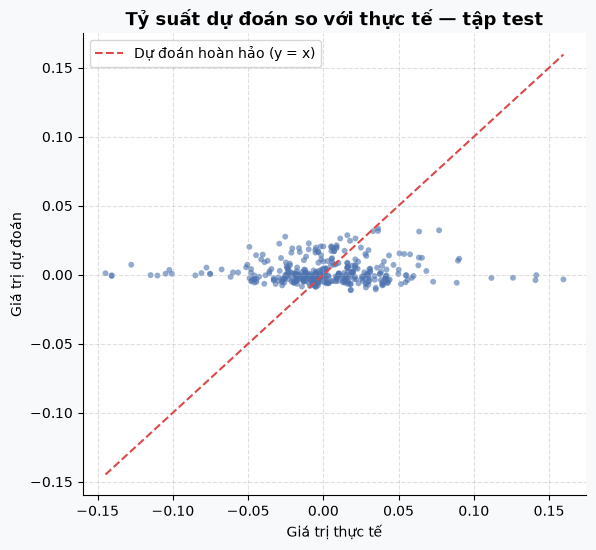

In [9]:
rfPlot.plot_predicted_versus_actual(
    test_targets, evaluations['test']['predictions'],
    title='Tỷ suất dự đoán so với thực tế — tập test',
)
plt.show()

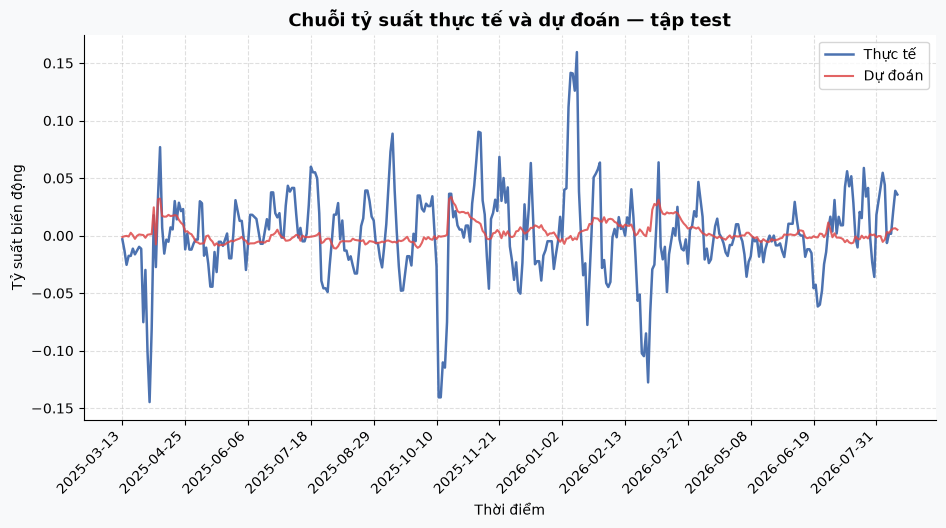

In [10]:
rfPlot.plot_series_comparison(
    test_targets, evaluations['test']['predictions'],
    index_labels=[str(key) for key in test_keys],
    title='Chuỗi tỷ suất thực tế và dự đoán — tập test',
    x_label='Thời điểm', y_label='Tỷ suất biến động',
)
plt.show()

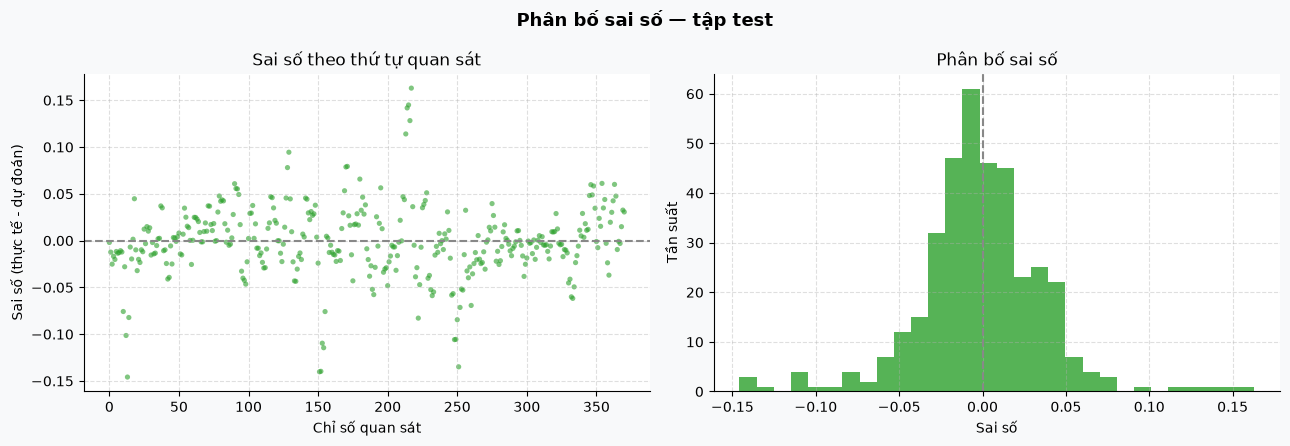

In [11]:
rfPlot.plot_residuals(
    test_targets, evaluations['test']['predictions'],
    title='Phân bố sai số — tập test',
)
plt.show()

## 8. Bắc cầu sang nhánh A

`Directional Accuracy` là chỉ số chung của hai nhánh: nhánh B suy chiều biến động
từ **dấu** của tỷ suất dự đoán, còn nhánh A học thẳng chiều đó. Đặt hai con số
cạnh nhau cho biết việc bắt mô hình học thêm **độ lớn** có giúp đoán **hướng** tốt
hơn hay không.

In [12]:
for name in ('validation', 'test'):
    print(f"{name:<12} directional accuracy = "
          f"{evaluations[name]['directional_accuracy']:.4f}")

print('\n→ So con số này với Accuracy của nhánh A trong 03_train_classify.ipynb.')

validation   directional accuracy = 0.6137
test         directional accuracy = 0.5192

→ So con số này với Accuracy của nhánh A trong 03_train_classify.ipynb.


Bước tiếp theo: [`05_baseline_sklearn.ipynb`](05_baseline_sklearn.ipynb) —
đối chiếu cài đặt thuần Python với scikit-learn.